In [1]:
%pip install --upgrade openai

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import image_tagger as it
from matplotlib import pyplot as plt

In [4]:
%load_ext autoreload
%autoreload 2

In [9]:
input_dir = r"C:\Users\oloon\Dropbox\images\uploads"
output_dir = input_dir
metadata_filename = os.path.join(output_dir, "image_metadata.csv")
gallery_filename = os.path.join(output_dir, "index.html")

In [10]:
# it.scramble_image_directory(input_dir, output_dir)

In [12]:
filepaths = it.find_images(input_dir, metadata_filename=metadata_filename)
print("number of image files:", len(filepaths))
filepaths

number of image files: 7


['C:\\Users\\oloon\\Dropbox\\images\\uploads\\blonde_woman_white_gown.png',
 'C:\\Users\\oloon\\Dropbox\\images\\uploads\\consciousness_brain_book_cover.jpg',
 'C:\\Users\\oloon\\Dropbox\\images\\uploads\\rest_robots_asimov_cover.jpg',
 'C:\\Users\\oloon\\Dropbox\\images\\uploads\\seated_nude_woman_flowers.jpg',
 'C:\\Users\\oloon\\Dropbox\\images\\uploads\\slan_ae_van_vogt_cover.jpg',
 'C:\\Users\\oloon\\Dropbox\\images\\uploads\\surreal_floating_figure_landscape.jpg',
 'C:\\Users\\oloon\\Dropbox\\images\\uploads\\war_games_karl_hansen.jpg']

In [13]:
it.tag_images(filepaths, metadata_filename, verbose=2)

Using OpenAI (gpt-5.4)
{'description': 'A woman with long blonde hair stands against a plain dark gray wall, facing slightly to the side while looking forward. She wears a floor-length white satin gown with thin straps, a deep neckline, and a high slit that reveals one leg, paired with pointed white heels. A large black bow detail sits at her waist, creating a strong contrast against the dress. She holds two white cups in one hand and a dark item in the other, while bright light from the upper right side of the image casts a soft glow across the wall. The setting appears minimal, with a black carpeted floor, white baseboard, and a visible wall outlet near her feet.', 'category': 'photography', 'genre': 'drama', 'tags': 'woman;blonde hair;white gown;evening dress;satin dress;high slit;black bow;formalwear;heels;standing pose;indoor wall;minimal background;cups;fashion photography', 'filename_already_makes_sense': True, 'filename': 'blonde_woman_white_gown.png', 'clean_filename': 'blonde

In [14]:
import pandas as pd

metadata_df = pd.read_csv(metadata_filename)
print(metadata_df.shape)
print("n unique original filenames:", len(set(metadata_df["original_filename"])))
print("n unique clean filenames:", len(set(metadata_df["clean_filename"])))

# pd.set_option('display.max_rows', None)
# metadata_df[ metadata_df['clean_filename'].duplicated(keep=False) ].sort_values(['clean_filename'])[['original_filename', 'clean_filename']]

(16, 15)
n unique original filenames: 16
n unique clean filenames: 16


In [15]:
it.rename_images(metadata_filename, verbose=1)

In [16]:
it.generate_gallery(metadata_filename, gallery_filename)

Text(0.5, 0, 'Number of Images')

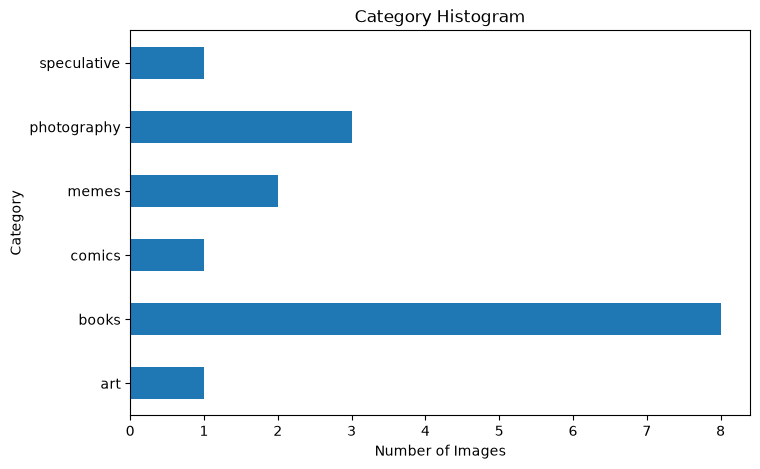

In [17]:
plt.figure(figsize=(8, 5))
metadata_df.groupby("category").size().plot.barh()
plt.title("Category Histogram")
plt.ylabel("Category")
plt.xlabel("Number of Images")

Text(0.5, 0, 'Number of Images')

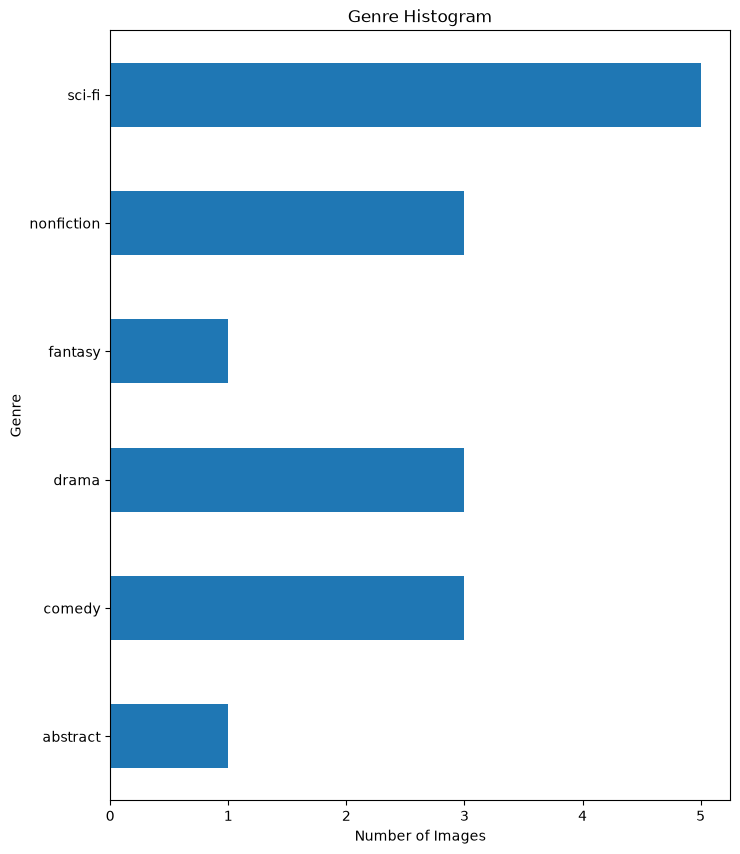

In [18]:
plt.figure(figsize=(8, 10))
metadata_df.groupby("genre").size().plot.barh()
plt.title("Genre Histogram")
plt.ylabel("Genre")
plt.xlabel("Number of Images")

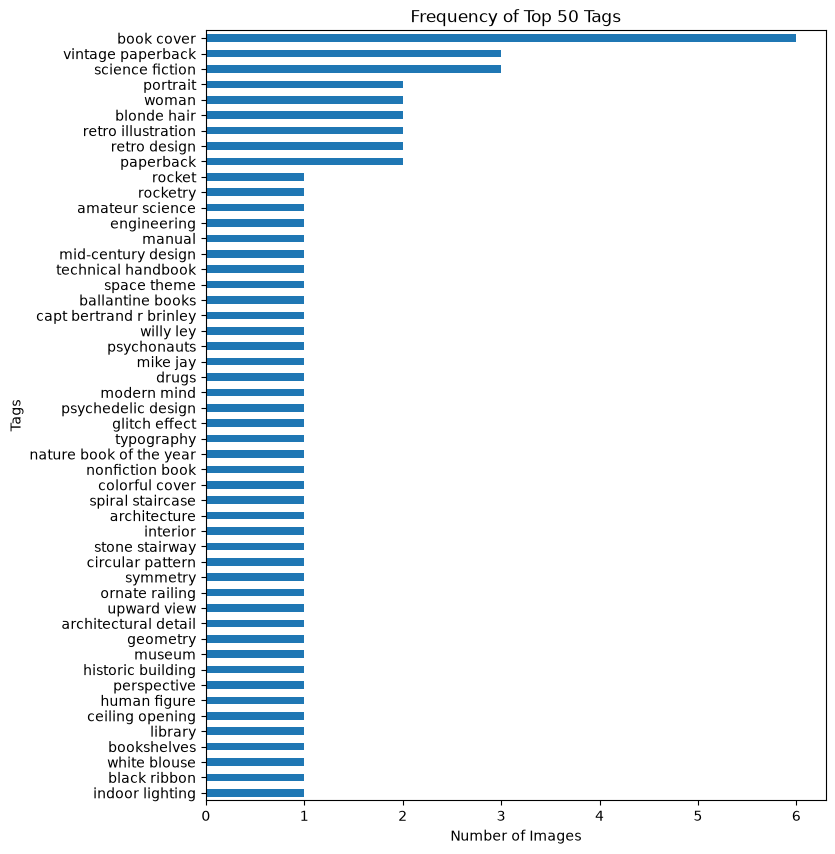

In [19]:
plt.figure(figsize=(8, 10))
tag_counts = metadata_df["tags"].str.split(";").explode("tags").value_counts()
N_TAGS = 50
top_tag_counts = tag_counts[:N_TAGS][::-1]
top_tag_counts.plot.barh()

plt.xlabel("Number of Images")
plt.ylabel("Tags")
plt.title(f"Frequency of Top {N_TAGS} Tags")
plt.show()

quartiles [-9.22337204e+09  3.22341000e-03  3.63216900e-03  4.31666425e-03
  1.16694766e+02]


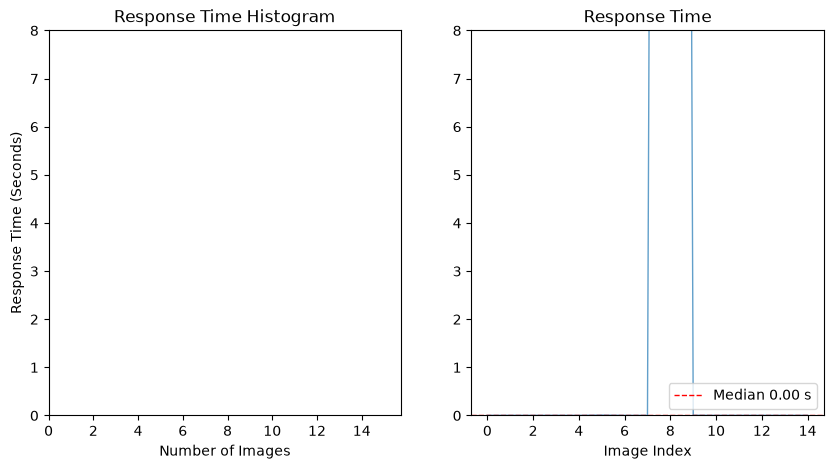

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
delta_seconds = np.array(
    pd.to_datetime(metadata_df["timestamp"]).diff().astype(np.int64) / 1e9
)

print("quartiles", np.quantile(delta_seconds, [0, 0.25, 0.5, 0.75, 1]))
bounds = np.quantile(delta_seconds, [0.05, 0.95])  # 90% CI
bounded = np.clip(delta_seconds, bounds[0], bounds[1])

plt.subplot(121)
plt.hist(bounded, bins=16, orientation="horizontal", rwidth=0.8)
plt.ylim(0, 8)
plt.ylabel("Response Time (Seconds)")
plt.xlabel("Number of Images")
plt.title("Response Time Histogram")

plt.subplot(122)
plt.plot(delta_seconds[1:], lw=1, alpha=0.7)
plt.ylim(0, 8)
median = np.median(delta_seconds)
plt.axhline(
    median, linestyle="dashed", label=f"Median {median:0.2f} s", color="red", lw=1
)
plt.legend(loc="lower right")
plt.xlabel("Image Index")
plt.title("Response Time");

In [21]:
cost = metadata_df["total_tokens"].sum() * 0.0000025
cost

np.float64(0.05603)